In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
import kagglehub

In [15]:
path = kagglehub.dataset_download("ashiksanyo/phishing-websites-dataset")

print("Files in dataset:", os.listdir(path))

df = pd.read_csv(os.path.join(path, "dataset_full.csv"))
print("Первые 5 строк:")
print(df.head())
print("\nРазмер датасета:", df.shape)
print("\nИнформация о столбцах:")
print(df.info())


Files in dataset: ['dataset_full.csv', 'dataset_small.csv']
Первые 5 строк:
   qty_dot_url  qty_hyphen_url  qty_underline_url  qty_slash_url  \
0            3               0                  0              1   
1            5               0                  1              3   
2            2               0                  0              1   
3            4               0                  2              5   
4            2               0                  0              0   

   qty_questionmark_url  qty_equal_url  qty_at_url  qty_and_url  \
0                     0              0           0            0   
1                     0              3           0            2   
2                     0              0           0            0   
3                     0              0           0            0   
4                     0              0           0            0   

   qty_exclamation_url  qty_space_url  ...  qty_ip_resolved  qty_nameservers  \
0                    0          

In [19]:
print("Столбцы датасета:")
print(df.columns)

target_col = "phishing"

X = df.drop(columns=[target_col])
y = df[target_col]

print("\nРазмер X:", X.shape)
print("Размер y:", y.shape)

print("\nРаспределение классов:")
print(y.value_counts())

print("\nПропуски:")
print(df.isnull().sum().sum())


Столбцы датасета:
Index(['qty_dot_url', 'qty_hyphen_url', 'qty_underline_url', 'qty_slash_url',
       'qty_questionmark_url', 'qty_equal_url', 'qty_at_url', 'qty_and_url',
       'qty_exclamation_url', 'qty_space_url',
       ...
       'qty_ip_resolved', 'qty_nameservers', 'qty_mx_servers', 'ttl_hostname',
       'tls_ssl_certificate', 'qty_redirects', 'url_google_index',
       'domain_google_index', 'url_shortened', 'phishing'],
      dtype='object', length=112)

Размер X: (88647, 111)
Размер y: (88647,)

Распределение классов:
phishing
0    58000
1    30647
Name: count, dtype: int64

Пропуски:
0


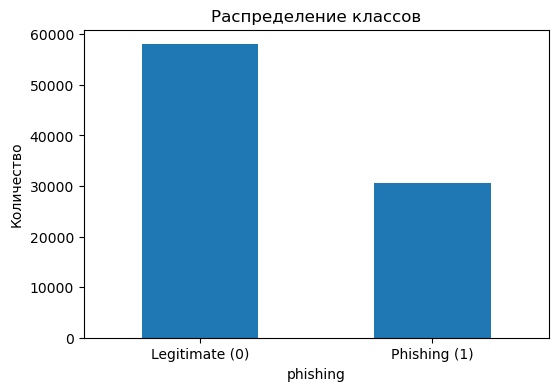

In [21]:
plt.figure(figsize=(6, 4))
df[target_col].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Legitimate (0)", "Phishing (1)"], rotation=0)
plt.title("Распределение классов")
plt.ylabel("Количество")
plt.show()


Признаки:
   qty_dot_url  qty_slash_url  qty_hyphen_url  qty_questionmark_url  \
0            3              1               0                     0   
1            5              3               0                     0   
2            2              1               0                     0   
3            4              5               0                     0   
4            2              0               0                     0   

   qty_equal_url  qty_at_url  qty_and_url  length_url  qty_tld_url  \
0              0           0            0          25            1   
1              3           0            2         223            3   
2              0           0            0          15            1   
3              0           0            0          81            1   
4              0           0            0          19            1   

   url_shortened  tls_ssl_certificate  phishing  
0              0                    0         1  
1              0                    1    

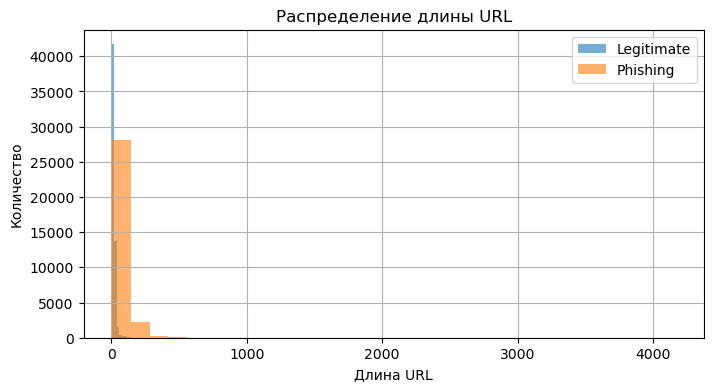

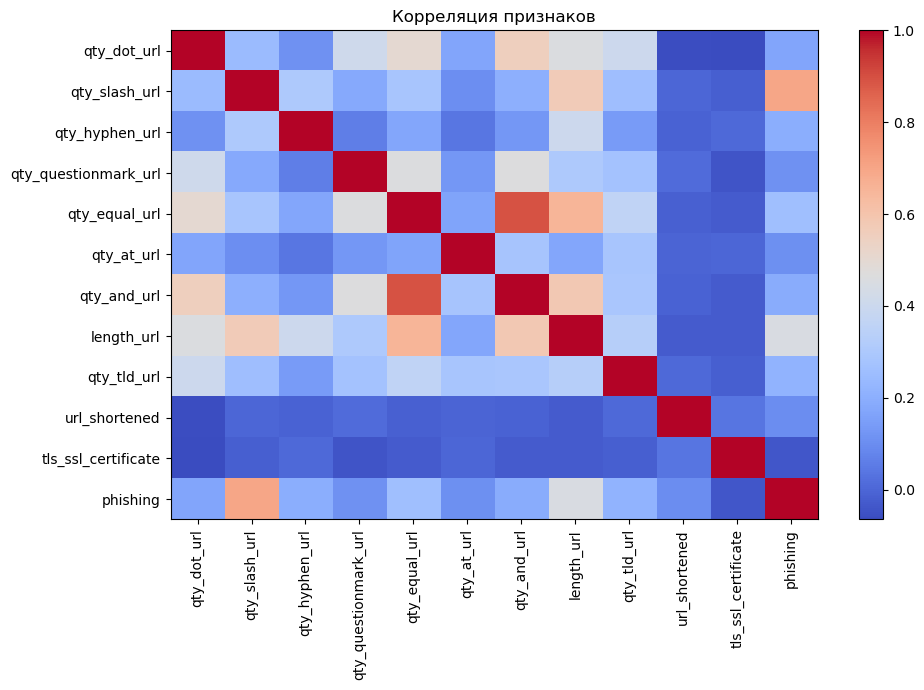


Размер X: (88647, 11)
Размер y: (88647,)

Распределение классов:
phishing
0    58000
1    30647
Name: count, dtype: int64


In [24]:
def get_domain(url: str) -> str:
    try:
        parsed = urlparse(url)
        domain = parsed.netloc
        if not domain:
            parsed = urlparse("http://" + url)
            domain = parsed.netloc
        return domain.lower()
    except:
        return ""

def get_path(url: str) -> str:
    try:
        parsed = urlparse(url)
        return parsed.path.lower()
    except:
        return ""

def has_ip_address(url: str) -> int:
    pattern = r"(?:\d{1,3}\.){3}\d{1,3}"
    return int(bool(re.search(pattern, url)))

def count_subdomains(domain: str) -> int:
    if not domain:
        return 0
    parts = domain.split(".")
    return max(len(parts) - 2, 0)

def has_suspicious_words(url: str) -> int:
    suspicious_words = [
        "login", "verify", "update", "secure", "account",
        "bank", "confirm", "password", "paypal", "bonus"
    ]
    url = url.lower()
    return int(any(word in url for word in suspicious_words))

def extract_url_features(url: str) -> dict:
    domain = get_domain(url)
    path = get_path(url)

    return {
        "url_length": len(url),
        "domain_length": len(domain),
        "dot_count": url.count("."),
        "slash_count": url.count("/"),
        "hyphen_count": url.count("-"),
        "digit_count": sum(char.isdigit() for char in url),
        "has_at_symbol": int("@" in url),
        "has_https": int(url.lower().startswith("https://")),
        "has_ip_address": has_ip_address(url),
        "subdomain_count": count_subdomains(domain),
        "has_suspicious_words": has_suspicious_words(url),
        "uses_shortener": int(bool(re.search(
            r"bit\.ly|goo\.gl|tinyurl\.com|t\.co|ow\.ly|is\.gd|buff\.ly",
            url.lower()
        )))
    }
target_col = "phishing"

selected_features = [
    "qty_dot_url",           # количество точек в URL
    "qty_slash_url",         # количество слэшей
    "qty_hyphen_url",        # количество дефисов
    "qty_questionmark_url",  # количество знаков ?
    "qty_equal_url",         # количество знаков =
    "qty_at_url",            # количество символов @
    "qty_and_url",           # количество символов &
    "length_url",            # длина URL
    "qty_tld_url",           # количество TLD / доменных зон
    "url_shortened",         # сокращённая ссылка или нет
    "tls_ssl_certificate"    # есть SSL/TLS сертификат или нет
]

# оставляем только нужные столбцы
df_features = df[selected_features + [target_col]].copy()

print("\nПризнаки:")
print(df_features.head())

print("\nКоличество признаков:", len(selected_features))

# визуализация 1: распределение длины URL по классам
plt.figure(figsize=(8, 4))
df_features[df_features[target_col] == 0]["length_url"].hist(alpha=0.6, bins=30, label="Legitimate")
df_features[df_features[target_col] == 1]["length_url"].hist(alpha=0.6, bins=30, label="Phishing")
plt.title("Распределение длины URL")
plt.xlabel("Длина URL")
plt.ylabel("Количество")
plt.legend()
plt.show()

# визуализация 2: корреляция признаков
plt.figure(figsize=(10, 7))
corr = df_features.corr()
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Корреляция признаков")
plt.tight_layout()
plt.show()

# X и y для обучения
X = df_features.drop(columns=[target_col])
y = df_features[target_col]

print("\nРазмер X:", X.shape)
print("Размер y:", y.shape)
print("\nРаспределение классов:")
print(y.value_counts())

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

# Если классы неравномерны, применим oversampling только к train
train_df = pd.concat([X_train, y_train], axis=1)

class_counts = train_df[target_col].value_counts()
print("\nКлассы в train до балансировки:")
print(class_counts)

majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

majority_df = train_df[train_df[target_col] == majority_class]
minority_df = train_df[train_df[target_col] == minority_class]

# Простая балансировка oversampling
minority_upsampled = resample(
    minority_df,
    replace=True,
    n_samples=len(majority_df),
    random_state=42
)

balanced_train_df = pd.concat([majority_df, minority_upsampled])
balanced_train_df = balanced_train_df.sample(frac=1, random_state=42).reset_index(drop=True)

X_train_balanced = balanced_train_df.drop(columns=[target_col])
y_train_balanced = balanced_train_df[target_col]

print("\nКлассы в train после балансировки:")
print(y_train_balanced.value_counts())


Train: (70917, 11) (70917,)
Test: (17730, 11) (17730,)

Классы в train до балансировки:
phishing
0    46400
1    24517
Name: count, dtype: int64

Классы в train после балансировки:
phishing
0    46400
1    46400
Name: count, dtype: int64


In [27]:
models = {
    "Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ]),
    
    "kNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=42))
    ]),
    
    "Decision Tree": Pipeline([
        ("model", DecisionTreeClassifier(random_state=42, max_depth=6))
    ]),
    
    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            random_state=42,
            class_weight="balanced"
        ))
    ])
}


Модель: Naive Bayes
Accuracy : 0.777
Precision: 0.8821
Recall   : 0.41
F1-score : 0.5598
ROC-AUC  : 0.9307

Classification report:
              precision    recall  f1-score   support

  Legitimate       0.76      0.97      0.85     11600
    Phishing       0.88      0.41      0.56      6130

    accuracy                           0.78     17730
   macro avg       0.82      0.69      0.71     17730
weighted avg       0.80      0.78      0.75     17730



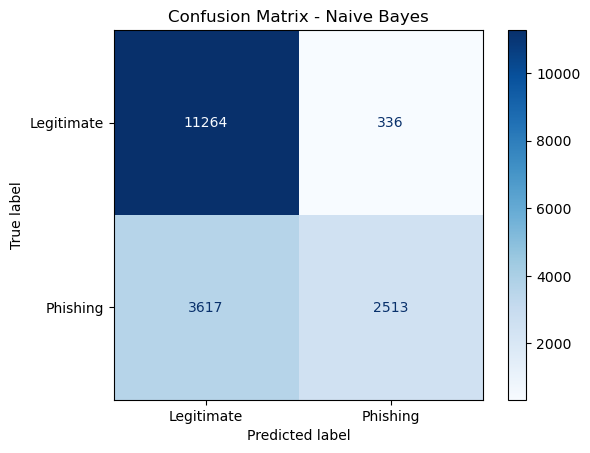

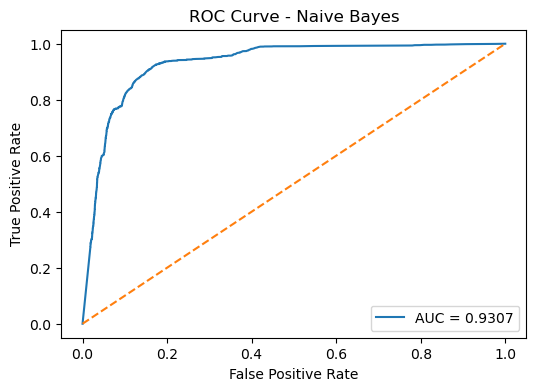


Модель: kNN
Accuracy : 0.8989
Precision: 0.8217
Recall   : 0.9038
F1-score : 0.8608
ROC-AUC  : 0.9522

Classification report:
              precision    recall  f1-score   support

  Legitimate       0.95      0.90      0.92     11600
    Phishing       0.82      0.90      0.86      6130

    accuracy                           0.90     17730
   macro avg       0.88      0.90      0.89     17730
weighted avg       0.90      0.90      0.90     17730



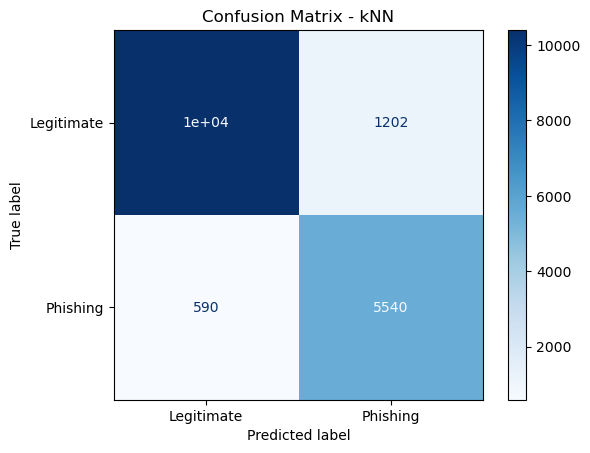

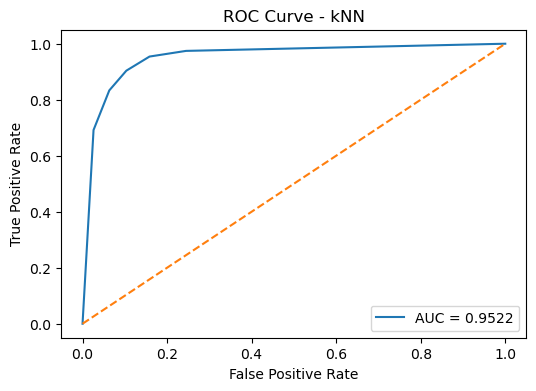


Модель: SVM
Accuracy : 0.8904
Precision: 0.7798
Recall   : 0.9515
F1-score : 0.8572
ROC-AUC  : 0.9562

Classification report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.86      0.91     11600
    Phishing       0.78      0.95      0.86      6130

    accuracy                           0.89     17730
   macro avg       0.88      0.90      0.88     17730
weighted avg       0.90      0.89      0.89     17730



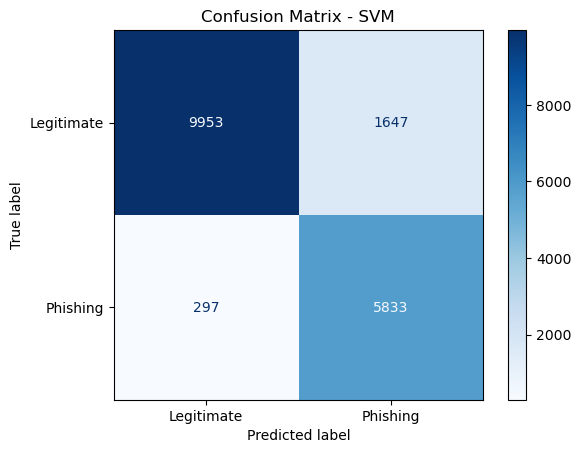

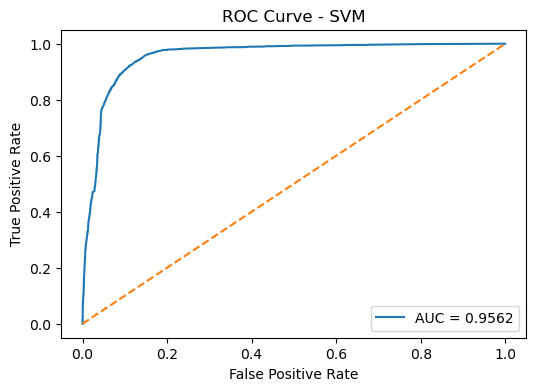


Модель: Decision Tree
Accuracy : 0.8916
Precision: 0.7863
Recall   : 0.9426
F1-score : 0.8574
ROC-AUC  : 0.9592

Classification report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.86      0.91     11600
    Phishing       0.79      0.94      0.86      6130

    accuracy                           0.89     17730
   macro avg       0.88      0.90      0.88     17730
weighted avg       0.90      0.89      0.89     17730



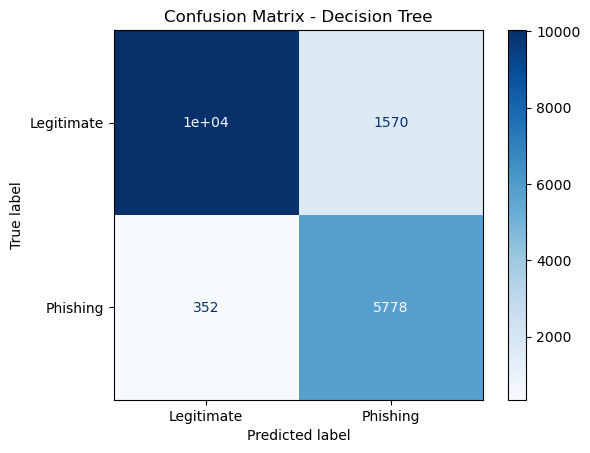

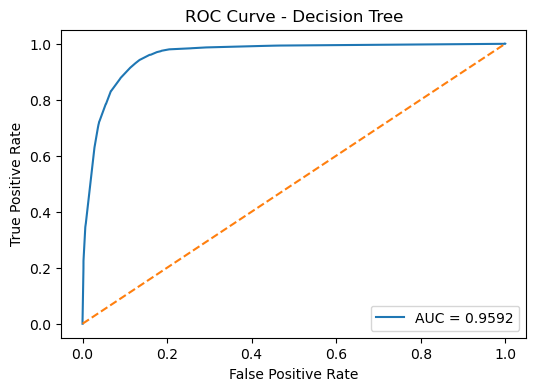


Модель: Random Forest
Accuracy : 0.8991
Precision: 0.7989
Recall   : 0.9463
F1-score : 0.8664
ROC-AUC  : 0.9693

Classification report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.87      0.92     11600
    Phishing       0.80      0.95      0.87      6130

    accuracy                           0.90     17730
   macro avg       0.88      0.91      0.89     17730
weighted avg       0.91      0.90      0.90     17730



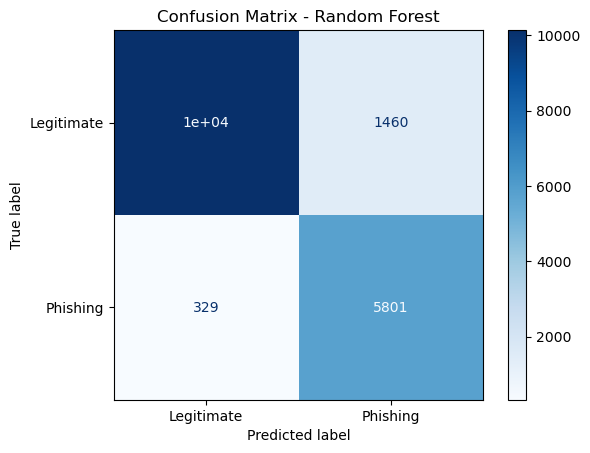

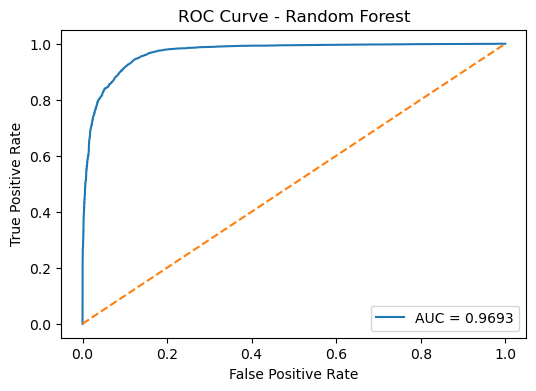


Итоговая таблица сравнения моделей:
           model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Random Forest  0.899098   0.798926  0.946330  0.866403  0.969255
1            kNN  0.898928   0.821715  0.903752  0.860783  0.952172
2  Decision Tree  0.891596   0.786336  0.942577  0.857397  0.959192
3            SVM  0.890355   0.779813  0.951550  0.857164  0.956207
4    Naive Bayes  0.777045   0.882064  0.409951  0.559751  0.930720


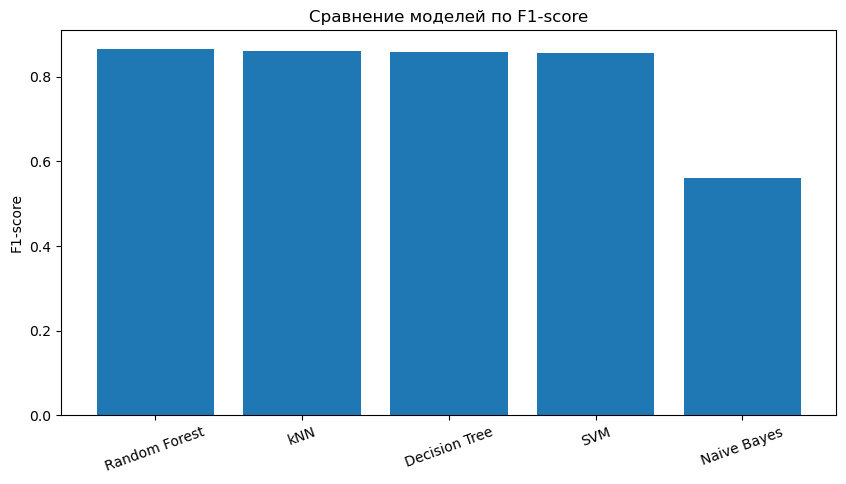

In [28]:
results = []

def evaluate_model(model_name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Вероятности для ROC-AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # На случай моделей без predict_proba
        y_proba = None
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    
    results.append({
        "model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": roc_auc
    })
    
    print(f"\n{'='*50}")
    print(f"Модель: {model_name}")
    print(f"{'='*50}")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4) if not np.isnan(roc_auc) else "N/A")
    
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=["Legitimate", "Phishing"]))
    
    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()
    
    # ROC-кривая
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {model_name}")
        plt.legend()
        plt.show()


for name, model in models.items():
    evaluate_model(
        name, model,
        X_train_balanced, y_train_balanced,
        X_test, y_test
    )

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False).reset_index(drop=True)

print("\nИтоговая таблица сравнения моделей:")
print(results_df)

plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["F1"])
plt.title("Сравнение моделей по F1-score")
plt.ylabel("F1-score")
plt.xticks(rotation=20)
plt.show()

In [ ]:
print("\nK-Fold cross-validation (5 folds):")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="f1")
    print(f"{name}: mean F1 = {scores.mean():.4f}, std = {scores.std():.4f}")


